# L20: Can a computer learn if we're going to detect gravitational waves?

**The goal here is to machine-learn the LIGO detectability: can we predict if a gravitational-wave source will be detected?**

This dataset contains simulated gravitational-wave signals from merging black holes (careful the file size is >1 GB). If you've never seen them, the .h5 format is a highly optimized storage strategy for large datasets. It's amazing. In python, you can read it with h5py.

In particular, each source has the following features:
- mtot: the total mass of the binary
- q: the mass ratio
- chi1x, chi1y, chi1z, chi2x, chi2y, chi2z: the components of the black-hole spins in a suitable reference frame.
- ra, dec: the location of the source in the sky
- iota: the inclination of the orbital plane'
- psi: the polarization angle (gravitational waves have two polarization states much like light)
- z: the redshift

The detectability is defined using the snr (signal-to-noise ratio) computed with a state-of-the-art model of the LIGO/Virgo detector network. All you need to know now is that we threshold the snr values and assume that LIGO will (not) see a source if snr>12 (snr<12). The resulting 0-1 labels are reported in the det attribute in the dataset.

Today's task is to train a classifier (you decide which one!) and separate sources that are detectables from those that aren't.

Be creative! This is a challenge! Let's see who gets the higher completeness and/or the smaller contamination (on a validation set, of course, careful with overfitting here).

**Tips:**

- You can downsample the data for debugging purposes
- You can also use only some of the features.
- Plot ROC curves
- Important Don't use snr as feature in your classifer (that's the answer...)

**Other ideas (optional)**

- Using the same data, we could run a regressor on snr instead of a classifier on det. We can then threshold the predictions (instead of tresholding the data like we're doing now). Would this give a better performance?
- How about trying to reduce the dimensionality of the dataset with a PCA-type algorithm to ease the classification problem?

In [1]:
!pip install h5py

In [2]:
import numpy as np
import pandas as pd
import h5py
import tqdm
from matplotlib import pyplot as plt
import corner
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, RocCurveDisplay, accuracy_score, ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, auc

In [10]:
file = './sample_2e7_design_precessing_higherordermodes_3detectors.h5'

with h5py.File(file, 'r') as f:
    print("Keys in file.h5:", list(f.keys()))
    
    data = {
        'mtot': f['mtot'][:],
        'q': f['q'][:],
        'chi1x': f['chi1x'][:], 
        'chi1y': f['chi1y'][:], 
        'chi1z': f['chi1z'][:],
        'chi2x': f['chi2x'][:], 
        'chi2y': f['chi2y'][:], 
        'chi2z': f['chi2z'][:],
        'ra': f['ra'][:], 
        'dec': f['dec'][:],
        'iota': f['iota'][:], 
        'psi': f['psi'][:], 
        'z': f['z'][:],
        'snr': f['snr'][:],
        'det': f['det'][:] 
    }

df = pd.DataFrame(data)

Keys in file.h5: ['chi1x', 'chi1y', 'chi1z', 'chi2x', 'chi2y', 'chi2z', 'dec', 'det', 'iota', 'mtot', 'psi', 'q', 'ra', 'snr', 'z']


In [11]:
print(f"Complete Dataset: {df.shape}")

Complete Dataset: (20000000, 15)


In [12]:
# I use only a fraction of the total dataset, since it's vere huge...
DEBUG_MODE = True
SAMPLE_FRACTION = 0.05  
if DEBUG_MODE:
    df = df.sample(frac=SAMPLE_FRACTION, random_state=42)
    print(f"Dataset (Downsampled): {df.shape}")


X = df.drop(columns=['det', 'snr']) # snr is the target!
y = df['det']

counts = np.bincount(y) # Detected by LIGO
total = len(y)

print(f"Not detected (0): {counts[0]} ({counts[0] / total * 100:.1f}%)")
print(f"Detected (1): {counts[1]} ({counts[1] / total * 100:.1f}%)")

# Train and Validation set (80% train, 20% validation)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

Dataset (Downsampled): (1000000, 15)
Not detected (0): 855575 (85.6%)
Detected (1): 144425 (14.4%)


## Decision Tree Classifier

In [13]:
drange = np.arange(1, 21)

dt = DecisionTreeClassifier(random_state=42, criterion='entropy')
grid_search = GridSearchCV(estimator=dt, param_grid={'max_depth': drange}, cv=5, scoring='roc_auc', n_jobs=-1)

grid_search.fit(X_train_scaled, y_train)

best_tree = grid_search.best_estimator_
best_depth = grid_search.best_params_['max_depth']
print("Best Maximal Depth:", best_depth)

Best Maximal Depth: 9


In [7]:
best_tree = DecisionTreeClassifier(max_depth=best_depth, random_state=42, criterion='entropy')
best_tree.fit(X_train_scaled, y_train)

y_pred_tree = best_tree.predict(X_val_scaled)
y_prob_tree = best_tree.predict_proba(X_val_scaled)[:, 1]

auc_score_tree = roc_auc_score(y_val, y_prob_tree)
print(f'AUC Decision Tree : {auc_score_tree}')

AUC Decision Tree : 0.9883763134459695


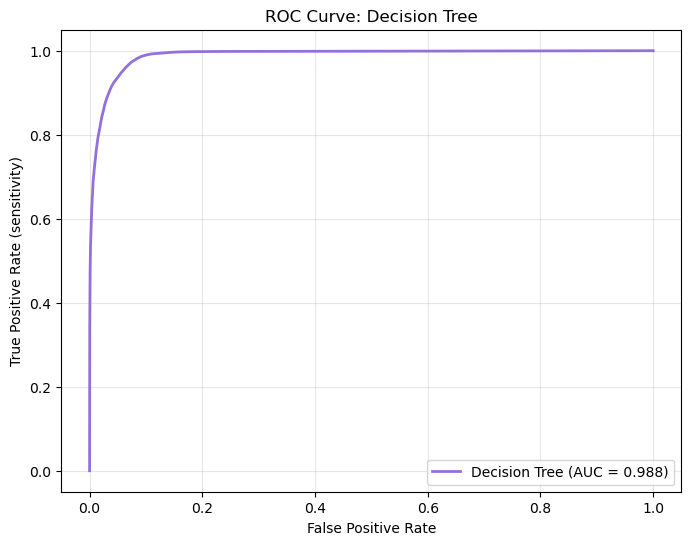

In [8]:
fpr_tree, tpr_tree, thresh_tree = roc_curve(y_val, y_prob_tree)
roc_auc_tree = auc(fpr_tree, tpr_tree)

plt.figure(figsize=(8,6))
plt.plot(fpr_tree, tpr_tree, lw=2, label=f"Decision Tree (AUC = {roc_auc_tree:.3f})", color='mediumpurple')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (sensitivity)')
plt.title('ROC Curve: Decision Tree')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

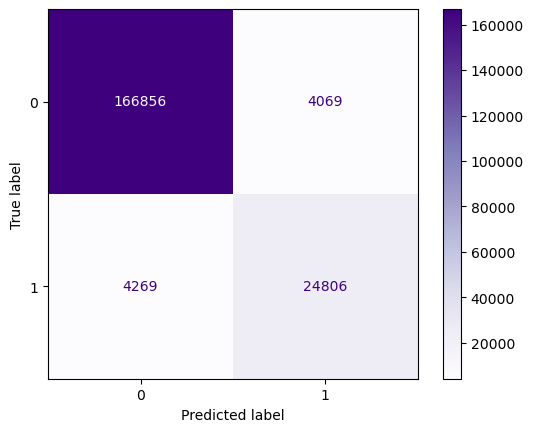

Completeness: 0.8532
Contamination: 0.1409


--- Feature Importances ---
z        0.835410
mtot     0.070725
iota     0.057327
q        0.022705
chi1z    0.012919
dtype: float64


In [9]:
cm_tree = confusion_matrix(y_val, y_pred_tree)

disp_tree = ConfusionMatrixDisplay(confusion_matrix=cm_tree)
disp_tree.plot(cmap='Purples')
plt.show()

tn_tree, fp_tree, fn_tree, tp_tree = cm_tree.ravel()

completeness = tp_tree / (tp_tree + fn_tree) if (tp_tree + fn_tree) > 0 else 0
contamination = fp_tree / (tp_tree + fp_tree) if (tp_tree + fp_tree) > 0 else 0

print(f"Completeness: {completeness:.4f}")
print(f"Contamination: {contamination:.4f}\n")

feature_importances_tree = pd.Series(best_tree.feature_importances_, index=X.columns)
print("\n--- Feature Importances ---")
print(feature_importances_tree.sort_values(ascending=False).head(5))

Not bad... but let's see if something gets better using the Random Forest

## Random Forest Classifier

In [17]:
rf = RandomForestClassifier(n_estimators=100, max_depth=best_depth, criterion='entropy', n_jobs=-1, random_state=42)

rf.fit(X_train_scaled, y_train)

y_pred_rf = rf.predict(X_val_scaled)
y_prob_rf = rf.predict_proba(X_val_scaled)[:, 1]

auc_score_rf = roc_auc_score(y_val, y_prob_rf)
print(f"AUC Random Forest: {auc_score_rf:.4f}")

AUC Random Forest: 0.9887


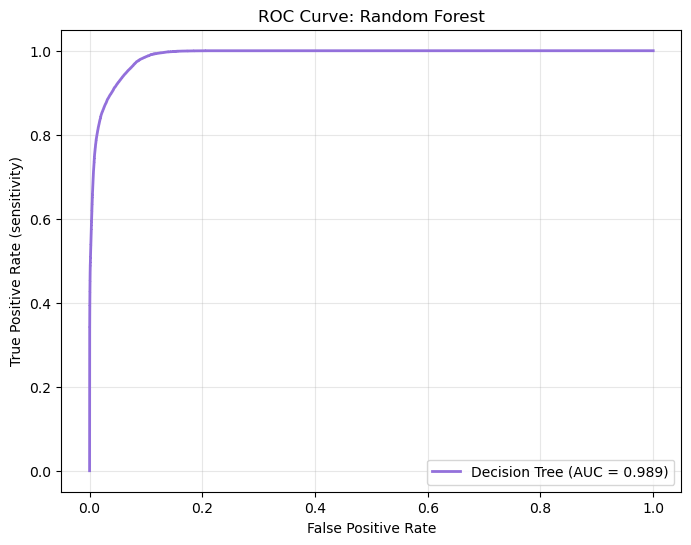

In [18]:
fpr_rf, tpr_rf, thresh_rf = roc_curve(y_val, y_prob_rf)
roc_auc_rf = auc(fpr_rf, tpr_rf)

plt.figure(figsize=(8,6))
plt.plot(fpr_rf, tpr_rf, lw=2, label=f"Decision Tree (AUC = {roc_auc_rf:.3f})", color='mediumpurple')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (sensitivity)')
plt.title('ROC Curve: Random Forest')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

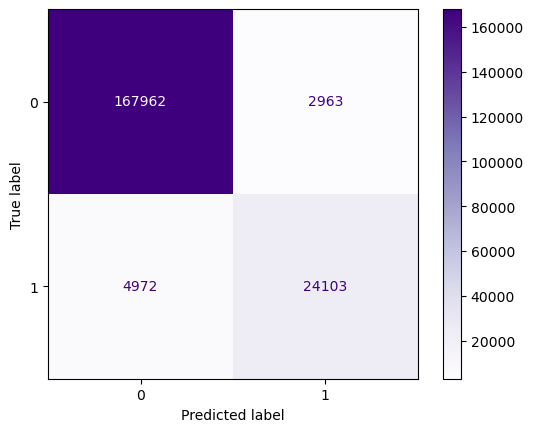

Completeness: 0.8290
Contamination: 0.1095


--- Feature Importances ---
z        0.905498
mtot     0.040173
iota     0.024088
q        0.014511
chi1z    0.008666
dtype: float64


In [19]:
cm_rf = confusion_matrix(y_val, y_pred_rf)
cm_rf = confusion_matrix(y_val, y_pred_rf)

disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf)
disp_rf.plot(cmap='Purples')
plt.show()

TN_rf, FP_rf, FN_rf, TP_rf = cm_rf.ravel()

completeness_rf = TP_rf / (TP_rf + FN_rf) if (TP_rf + FN_rf) > 0 else 0
contamination_rf = FP_rf / (TP_rf + FP_rf) if (TP_rf + FP_rf) > 0 else 0

print(f"Completeness: {completeness_rf:.4f}")
print(f"Contamination: {contamination_rf:.4f}\n")

feature_importances_rf = pd.Series(rf.feature_importances_, index=X.columns)
print("\n--- Feature Importances ---")
print(feature_importances_rf.sort_values(ascending=False).head(5))

**As we can see, the most important features for determining the dectability are redshift and total mass of the binary.** \
So we can try to visualize how these two characteristics determine the detectability of the gravitational wave by LIGO

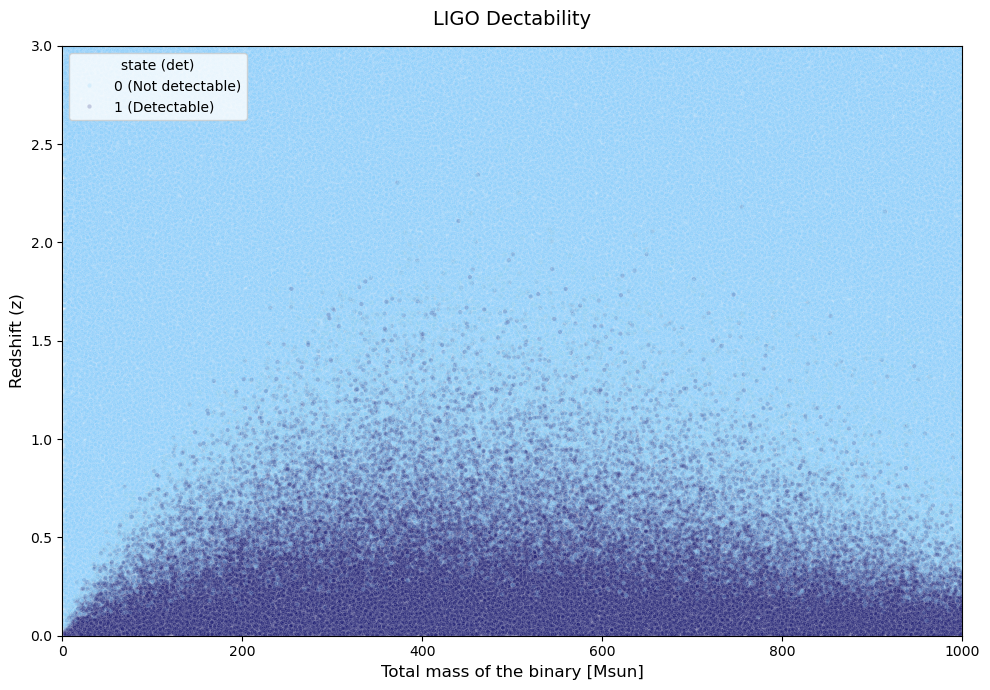

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))

subsample=df.sample(n=800000, random_state=42)
ax = sns.scatterplot(data=subsample, x='mtot', y='z', hue='det', palette={0: 'lightskyblue', 1: 'midnightblue'}, alpha=0.2, s=10)

plt.title('LIGO Dectability', fontsize=14, pad=15)
plt.xlabel('Total mass of the binary [Msun]', fontsize=12)
plt.ylabel('Redshift (z)', fontsize=12)
plt.ylim(0,3)
plt.xlim(0,1000)

handles, labels = ax.get_legend_handles_labels()
plt.legend(handles=handles, labels=['0 (Not detectable)', '1 (Detectable)'], title='state (det)', loc='upper left')

plt.tight_layout()
plt.show()

- If two black holes merge near us (low z), the signal reaches us loud (dark points). If they're on the other side of the universe (high z), the signal arrives too weak, gets drowned out by the detector's background noise, and LIGO lose it (light points).
- The range of detectability of a ground detector depends strongly on the frequency of the signal. For ground-based detectors (such as LIGO) the mass range of the black hole binary to which they are sensitive is from 1 to a few hundred solar masses... The higher is the mass, the lower is the frequency! That's why the signal coming from very massive binaries is not detectable by LIGO

## PCA reduction

In [6]:
from sklearn.decomposition import PCA

In [7]:
n_comp = X_train_scaled.shape[1]
print(n_comp)

pca = PCA(n_components=n_comp)
X_pca = pca.fit_transform(X_train_scaled)

13


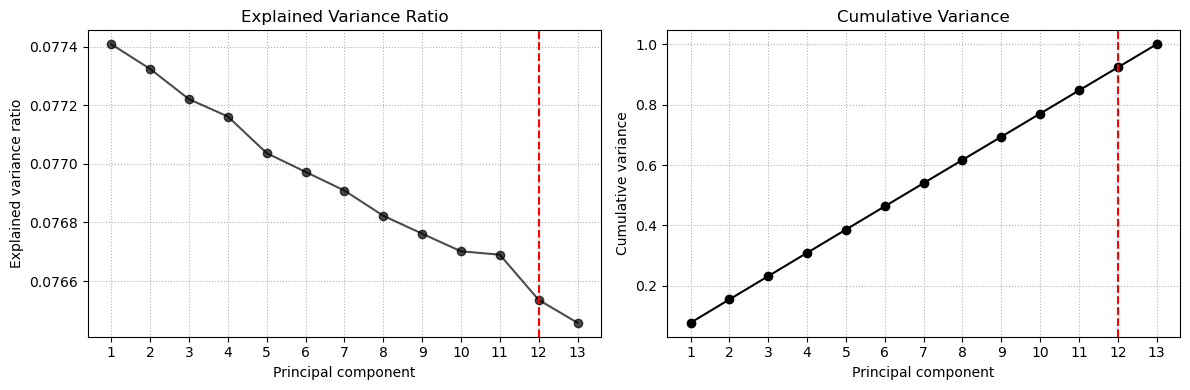

Number of Principal components required for a cumulative variance > 90%: 12


In [8]:
# Explained variance ratio and cumulative variance
exp_var = pca.explained_variance_ratio_
cum_exp_var = np.cumsum(exp_var)

threshold = 0.90
elbow_index = np.argmax(cum_exp_var >= threshold)+1

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

# 1. plot explained variance
ax[0].plot(range(1, len(exp_var) + 1), exp_var, marker='o', linestyle='-', color='black', alpha=0.7, label='Explained variance')
ax[0].axvline(elbow_index, color='red', linestyle='--', label=f"Elbow at PC{elbow_index}")
ax[0].set_ylabel('Explained variance ratio')
ax[0].set_xlabel('Principal component')
ax[0].set_xticks(range(1, len(exp_var) + 1))
ax[0].set_title("Explained Variance Ratio")
ax[0].grid(True, linestyle=':')


# 2. plot cumulative variance
ax[1].plot(range(1, len(cum_exp_var) + 1), cum_exp_var, marker='o', linestyle='-', label='Cumulative variance', color='black')
ax[1].axvline(elbow_index, color='red', linestyle='--', label=f"Elbow at PC{elbow_index}")
ax[1].set_ylabel('Cumulative variance')
ax[1].set_xlabel('Principal component')
ax[1].set_xticks(range(1, len(exp_var) + 1))
ax[1].set_title("Cumulative Variance")
ax[1].grid(True, linestyle=':')

plt.tight_layout()
plt.show()

print(f"Number of Principal components required for a cumulative variance > 90%: {elbow_index}")

As can be seen from the Explained Variance plot, the dataset is composed of largely **independent variables**. Since **PCA is an unsupervised method**, it simply maps the geometric variance of the parameter space without knowing the target (detectability). Consequently, it fails to recognize that the signal-to-noise ratio (SNR) depends almost entirely on the nonlinear physical relationships between distance (z) and mass (mtot), as demonstrated previously.

In [14]:
pca_rf = PCA(n_components=elbow_index, random_state=42)

X_train_pca = pca_rf.fit_transform(X_train_scaled)
X_val_pca = pca_rf.transform(X_val_scaled)

print(f"Original dimensions : {X_train_scaled.shape[1]} features")
print(f"Dimensions after PCA reduction : {X_train_pca.shape[1]} principal components")

rf_pca = RandomForestClassifier(n_estimators=100, max_depth=best_depth, criterion='entropy', n_jobs=-1, random_state=42)
rf_pca.fit(X_train_pca, y_train)

y_pred_pca = rf_pca.predict(X_val_pca)
y_prob_pca = rf_pca.predict_proba(X_val_pca)[:,1]

Original dimensions : 13 features
Dimensions after PCA reduction : 12 principal components


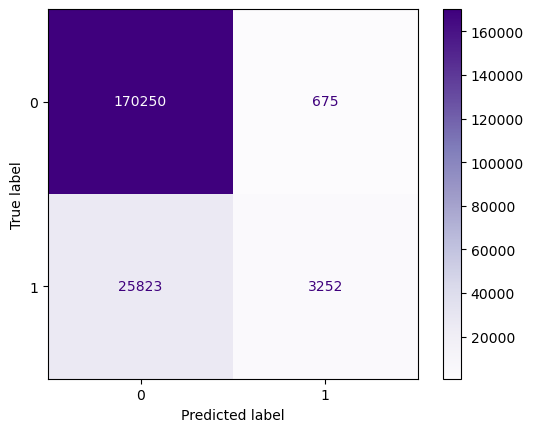

Random Forest (13 features)
Completeness : 0.8290
Contamination: 0.1095

Random Forest (PCA compression)
Completeness : 0.1118
Contamination: 0.1719


In [20]:
cm_pca = confusion_matrix(y_val, y_pred_pca)

disp_pca = ConfusionMatrixDisplay(confusion_matrix=cm_pca)
disp_pca.plot(cmap='Purples')
plt.show()

TN_p, FP_p, FN_p, TP_p = cm_pca.ravel()

completeness_pca = TP_p / (TP_p + FN_p) if (TP_p + FN_p) > 0 else 0
contamination_pca = FP_p / (TP_p + FP_p) if (TP_p + FP_p) > 0 else 0

print(f"Random Forest (13 features)")
print(f"Completeness : {completeness_rf:.4f}")
print(f"Contamination: {contamination_rf:.4f}\n")

print(f"Random Forest (PCA compression)")
print(f"Completeness : {completeness_pca:.4f}")
print(f"Contamination: {contamination_pca:.4f}")

PCA is not a suitable approach for this specific astrophysical problem. Moving from the original 13 features to the principal components, the classifier's performance dropped dramatically (completeness from $\sim 82\%$ to $\sim 10\%$).
This is because PCA is a linear, unsupervised transformation: in compressing the variance, it mixed physical variables that are crucial for the signal-to-noise ratio (such as $m_{tot}$ and $z$) with "useless" variables (such as $ra$ and $dec$, which have high geometric variance but no predictive power).